In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math

In [2]:
airbnb = pd.read_csv('AB_NYC_2019.csv')
titanic = pd.read_csv('Titanic-Dataset.csv')

In [3]:
airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#Q1) Create FamilySize = SibSp + Parch + 1
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [ ]:
#Q2) Create IsAlone binary column from FamilySize
titanic['isAlone'] = titanic['FamilySize'].apply(lambda x : True if x == 1 | 0 else False)
titanic.head()

In [ ]:
#Q3) Extract title from Name column (Mr, Mrs, Miss, etc.) using regex

titanic['Name'] = titanic['Name'].str.replace('Mr. ', '', regex=True)
titanic['Name'] = titanic['Name'].str.replace('Mrs. ', '', regex=True)
titanic['Name'] = titanic['Name'].str.replace('Miss. ', '', regex=True)
print(titanic.head())


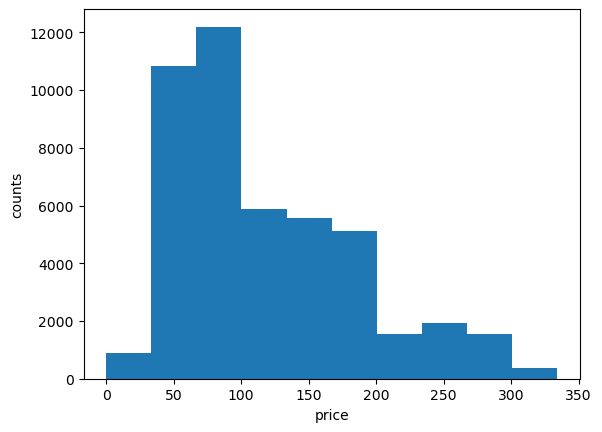

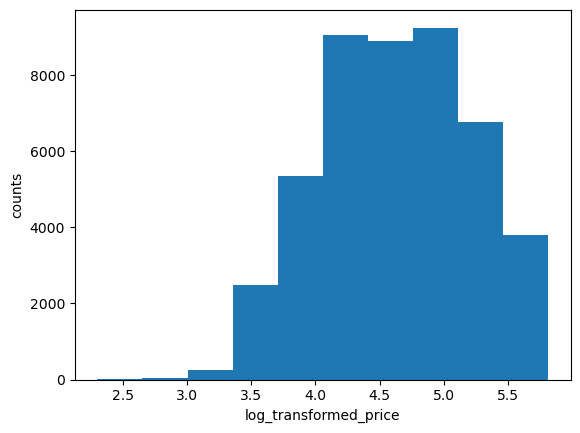

In [6]:
#Q4) Log-transform Airbnb price — plot the distribution before and after

p_25, p_75 = np.percentile(airbnb['price'], 25), np.percentile(airbnb['price'], 75)

IQR = p_75 - p_25
cut_off = 1.5 * IQR
lower_bound = p_25 - cut_off
upper_bound = p_75 + cut_off

def classify(price):
    if price < lower_bound:
        return True
    elif price > upper_bound:
        return True
    else:
        return False

airbnb['is_outlier'] = airbnb['price'].apply(classify)

airbnb = airbnb[airbnb['is_outlier'] == False]

#Before log_transformation

plt.hist(airbnb['price'])
plt.xlabel('price')
plt.ylabel('counts')
plt.show()

airbnb = airbnb[airbnb['price'] != 0]

airbnb['log_transformed'] = airbnb['price'].transform(lambda x: np.log(x))

#After log_transformation
plt.hist(airbnb['log_transformed'])
plt.xlabel('log_transformed_price')
plt.ylabel('counts')
plt.show()

In [7]:
#Q5) One-hot encode room_type
df_encoded = pd.get_dummies(airbnb['room_type'], dtype=int)
airbnb = pd.concat([airbnb, df_encoded], axis = 1)
airbnb.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'is_outlier', 'log_transformed', 'Entire home/apt',
       'Private room', 'Shared room'],
      dtype='object')

In [8]:
#Q6) Bin minimum_nights into categories

p_25, p_75 = np.percentile(airbnb['minimum_nights'], 25), np.percentile(airbnb['minimum_nights'], 75)

IQR = p_75 - p_25
cut_off = 1.5 * IQR
lower_bound = p_25 - cut_off
upper_bound = p_75 + cut_off

def classify(price):
    if price < lower_bound:
        return True
    elif price > upper_bound:
        return True
    else:
        return False

airbnb['is_outlier_min_nights'] = airbnb['minimum_nights'].apply(classify)

airbnb = airbnb[airbnb['is_outlier_min_nights'] == False]

def classify_minimum_nights(minimum_night):
    if minimum_night <= 3:
        return "low"
    elif 3 < minimum_night <= 7:
        return "medium"
    else:
        return "high"

airbnb['classified_minimum_nights'] = airbnb['minimum_nights'].apply(classify_minimum_nights)

airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,reviews_per_month,calculated_host_listings_count,availability_365,is_outlier,log_transformed,Entire home/apt,Private room,Shared room,is_outlier_min_nights,classified_minimum_nights
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,...,0.21,6,365,False,5.003946,0,1,0,False,low
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,...,0.38,2,355,False,5.416100,1,0,0,False,low
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,...,NaN,1,365,False,5.010635,0,1,0,False,low
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,...,4.64,1,194,False,4.488636,1,0,0,False,low
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,...,0.10,1,0,False,4.382027,1,0,0,False,high
